In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ler dataset CSV
# Supondo que o arquivo esteja no mesmo diretório
X = np.genfromtxt("dataset_clientes_kmeans.csv", delimiter=",", skip_header=1)

In [6]:
# 2. Função da distância euclidiana
def euclidian_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

In [7]:
# 3. Implementação K-means
def kmeans(X, k=3, max_iter=100):
    # 1. Inicializar centróides escolhendo k pontos aleatórios
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx]

    for _ in range(max_iter):
        # 2. Associação - escolher centróide mais próximo
        clusters = [[] for _ in range(k)]
        labels = np.zeros(len(X))

        for i, point in enumerate(X):
            distances = euclidian_distance(point, centroids)
            label = np.argmin(distances)
            clusters[label].append(point)
            labels[i] = label

        # 3. Guardar centróides antigos
        old_centroids = centroids.copy()

        # 4. Atualizar centróides
        for i in range(k):
            if clusters[i]:
                centroids[i] = np.mean(clusters[i], axis=0)

        # 5. Critério de parada
        if np.allclose(centroids, old_centroids):
            break
    
    return centroids, labels

In [8]:
# 4. Executar o k-means
centroids, labels = kmeans(X, k=3)

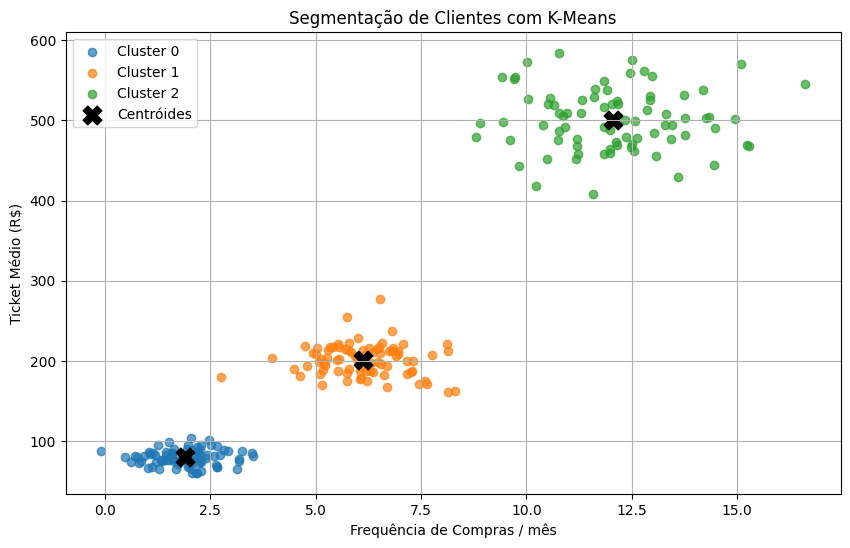

In [9]:
# 5. Plotar resultados
plt.figure(figsize=(10, 6))

for cluster_id in np.unique(labels):
    plt.scatter(
        X[labels == cluster_id, 0],
        X[labels == cluster_id, 1],
        alpha=0.7,
        label=f"Cluster {int(cluster_id)}"
    )

plt.scatter(
    centroids[:, 0], centroids[:, 1], s=180, c="black", marker="X", label="Centróides"
)

plt.title("Segmentação de Clientes com K-Means")
plt.xlabel("Frequência de Compras / mês")
plt.ylabel("Ticket Médio (R$)")
plt.legend()
plt.grid(True)
plt.show()